## PRACTICAL 9

**NAME: VARAD VIJAY AMBEKAR**

**CLASS:SY-A**

**ROLLNO: A-02**

**Aim - Building a Simple Data Science Pipeline: Integrate all learned techniques in previous labs into a complete workflow.**

**Q1. What is a Data Science Pipeline?**

A Data Science Pipeline is a step-by-step process used to convert raw data into useful results or predictions.

Stages:
Data Collection – collecting data (CSV, database)
Data Cleaning – removing missing or wrong data
EDA (Exploration) – understanding patterns in data
Feature Engineering – creating new useful columns
Encoding & Scaling – converting data into proper format
Model Training – applying machine learning model
Evaluation – checking model performance

* Example: Predicting student marks based on study hours.

**Q2. What is EDA?**

EDA (Exploratory Data Analysis) is the process of analyzing data to understand it before applying machine learning.

Types:
Univariate Analysis – study one column

Example: checking distribution of marks

Bivariate Analysis – study relationship between two columns

Example: study hours vs marks

* It helps in finding patterns, trends, and errors.

**Q3. Label Encoding vs OneHot Encoding**

| Feature           | Label Encoding                            | OneHot Encoding                                |
| ----------------- | ----------------------------------------- | ---------------------------------------------- |
| Definition        | Converts categories into numerical labels | Converts categories into binary columns        |
| Example           | Red = 0, Blue = 1, Green = 2              | Red = [1,0,0], Blue = [0,1,0], Green = [0,0,1] |
| Number of Columns | 1 column                                  | Multiple columns                               |
| Order Issue       | Creates order (can mislead model)         | No order is created                            |
| Suitable For      | Ordinal data (Low, Medium, High)          | Nominal data (Color, City)                     |
| Model Impact      | Can cause wrong interpretation            | Gives better accuracy in many cases            |

**Q4. Why is Feature Scaling Required?**


Feature scaling is used to bring all features to a similar range so that no feature dominates others during model training.

In real datasets, features have different ranges. For example, age may range from 18–60, while salary may range from 10,000–1,00,000. Without scaling, machine learning models may give more importance to larger values like salary and ignore smaller ones like age.

* Feature scaling helps in:

Improving model accuracy

Increasing training speed

Helping algorithms converge faster

* It is mainly required in algorithms like:

Linear Regression

KNN

SVM

**Types of Feature Scaling**

1. Normalization (Min-Max Scaling):

Scales values between 0 and 1
Formula:
X' = (X − min) / (max − min)
Used when data has no extreme outliers

2. Standardization (Z-score Scaling):

Converts data to mean = 0 and standard deviation = 1
Formula:
X' = (X − μ) / σ
Used in most real-world datasets (handles outliers better)
Difference
Feature	Normalization	Standardization
Range	0 to 1	No fixed range
Outliers	Affected	Handles better
Use Case	Neural networks	Most ML models

**Q5. What is Feature Engineering?**

Feature engineering is the process of creating new features from existing data to improve the performance of a machine learning model.

Raw data is often not enough for accurate predictions. By transforming or combining features, we can provide better input to the model.

**Importance**
Improves model accuracy

Helps in better pattern detection

Reduces noise in data

Makes models more efficient

Types of Feature Engineering

1. Creating New Features

Example:
Total Marks = Math + Science + English

2. Transforming Features

Example:
Applying log transformation to reduce large values

3. Extracting Features

Example:
From Date → Day, Month, Year

4. Combining Features

Example:
Income per person = Total income / family members

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/train (1).csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

df.fillna(df.mean(numeric_only=True), inplace=True)

df.drop_duplicates(inplace=True)

In [ ]:
df.corr(numeric_only=True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S


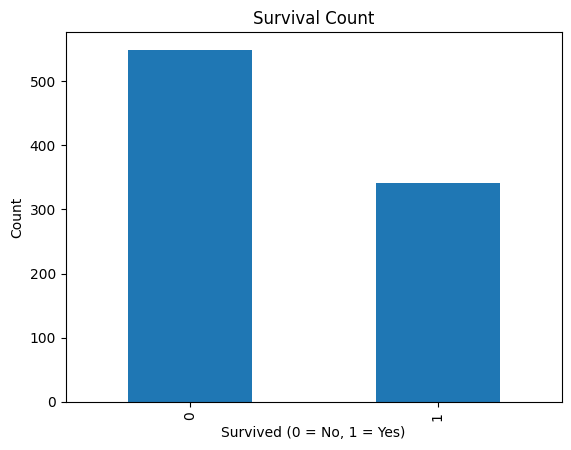

In [ ]:
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

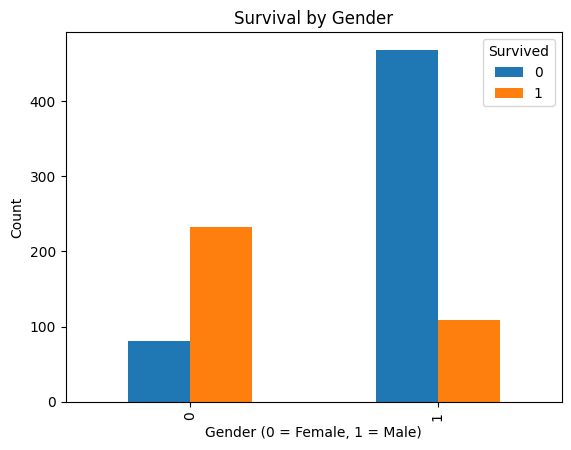

In [ ]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')
plt.title("Survival by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

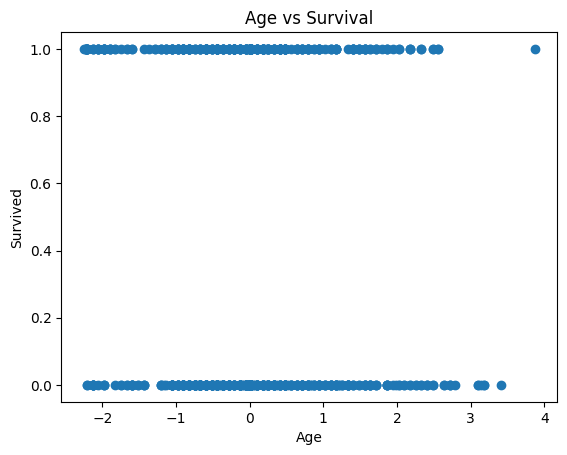

In [ ]:
plt.scatter(df['Age'], df['Survived'])
plt.title("Age vs Survival")
plt.xlabel("Age")
plt.ylabel("Survived")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
df['Age_Squared'] = df['Age'] ** 2

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Age', 'Fare', 'FamilySize', 'Age_Squared']] = scaler.fit_transform(
    df[['Age', 'Fare', 'FamilySize', 'Age_Squared']]
)

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
predictions = model.predict(X_test)
print(predictions)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1]


**Conclusion**

In this experiment, a complete data science pipeline was successfully implemented using the Titanic Dataset. The process included data cleaning, exploratory data analysis (EDA), feature engineering, encoding, scaling, and model building.

Through EDA, important patterns were observed, such as higher survival rates among females and first-class passengers. Feature engineering was performed by creating new features like FamilySize, which helped in improving the understanding of the data.

After preprocessing, a machine learning model was trained to predict survival. The pipeline demonstrated how raw data can be transformed into meaningful insights and predictions using systematic steps.

Overall, this experiment helped in understanding the importance of each stage in a data science workflow and how proper preprocessing and feature selection improve model performance.